## Practical 1 — From Real Biological Data to an ML-Ready Dataset
## Bladder cancer microarray data, data quality, grouping, and batch effects

## Learning goals

By the end of this practical, you should be able to:

- identify observations, features, metadata, targets, and technical variables in a real biological dataset;
- recognize the orientation and dimensionality of an expression matrix;
- apply tidy-data principles to biological measurements and metadata;
- perform systematic data diagnostics even when no obvious data-entry errors are present;
- transform a real expression dataset into an ML-ready representation;
- explain why repeated or highly related observations must remain in the same data split;
- distinguish **real batch structure** from an **artificial pseudo grouping**;
- detect evidence of batch effects and target–batch confounding;
- independently apply the same workflow to the UCI Mice Protein Expression dataset.

**Main idea:** a model sees numerical representations. It does not assume which variation is biological, technical, duplicated, or leaked across the train/test boundary.

# 0. Dataset check


We use the Bioconductor **`bladderbatch`** dataset: an Affymetrix microarray bladder-cancer dataset containing **57 samples, 22,283 probe-set expression measurements, and five processing batches**.

The Bioconductor metadata include:

- `sample` — sample number;
- `outcome` — original biological outcome;
- `batch` — processing batch defined by the date on which arrays were processed;
- `cancer` — a simplified biological outcome.

The expression data were RMA-normalized before inclusion in the package.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

DATA = Path(".")
RANDOM_STATE = 100926

In [2]:
expression_raw = pd.read_csv(DATA / "bladder_expression_raw.csv")
metadata = pd.read_csv(DATA / "bladder_metadata.csv")

print("Raw expression:", expression_raw.shape)
print("Metadata:", metadata.shape)

Raw expression: (22283, 58)
Metadata: (57, 5)


In [3]:
metadata

,sample_id,sample,outcome,batch,cancer
0,GSM71019.CEL,1,Normal,3,Normal
1,GSM71020.CEL,2,Normal,2,Normal
2,GSM71021.CEL,3,Normal,2,Normal
3,GSM71022.CEL,4,Normal,3,Normal
4,GSM71023.CEL,5,Normal,3,Normal
5,GSM71024.CEL,6,Normal,3,Normal
6,GSM71025.CEL,7,Normal,2,Normal
7,GSM71026.CEL,8,Normal,2,Normal
8,GSM71028.CEL,9,sTCC+CIS,5,Cancer
9,GSM71029.CEL,10,sTCC-CIS,2,Cancer


In [5]:
expression_raw.head()

,probe_set_id,GSM71019.CEL,GSM71020.CEL,GSM71021.CEL,GSM71022.CEL,GSM71023.CEL,GSM71024.CEL,GSM71025.CEL,GSM71026.CEL,GSM71028.CEL,...,GSM71068.CEL,GSM71069.CEL,GSM71070.CEL,GSM71071.CEL,GSM71072.CEL,GSM71073.CEL,GSM71074.CEL,GSM71075.CEL,GSM71076.CEL,GSM71077.CEL
0,1007_s_at,10.115170,8.628044,8.779235,9.248569,10.256841,10.023133,9.108034,8.735616,9.803271,...,10.582892,10.009028,9.912853,9.096809,9.011927,8.396062,8.903465,9.501538,9.540766,9.039143
1,1053_at,5.345168,5.063598,5.113116,5.179410,5.181383,5.248418,5.252312,5.220931,5.595771,...,5.615926,5.151548,5.237126,5.093278,5.353248,5.214357,5.251383,5.223598,5.191392,5.235880
2,117_at,6.348024,6.663625,6.465892,6.116422,5.980457,5.796155,6.414849,6.846798,5.841478,...,5.913488,5.904794,5.960948,6.394089,6.425034,6.372520,6.095344,5.811968,6.007461,6.314809
3,121_at,8.901739,9.439977,9.540738,9.254368,8.798086,8.002870,9.093704,9.263386,7.789240,...,8.049998,8.407351,8.985741,8.817789,8.866083,8.704385,9.375736,8.580523,8.848099,9.663298
4,1255_g_at,3.967672,4.466027,4.144885,4.189338,4.078509,3.919740,4.402590,4.173666,3.590649,...,3.775194,3.995371,4.322380,4.141255,3.997644,4.219360,4.454771,4.188310,4.284053,4.877523


## 1.2 Prepare the expression matrix for scikit-learn

The raw export preserves the original assay orientation: probe sets are rows and biological samples are columns. Most scikit-learn workflows/tidy data principles expect the opposite orientation: samples are rows and features are columns.

We now transpose the matrix in Python and use the sample identifiers from the column names as `sample_id`. The resulting `expression` table is the ML-ready expression table used below.

In [9]:
expression = expression_raw.set_index("probe_set_id").T.rename_axis("sample_id").reset_index()
expression.columns.name = None

print(expression_raw.shape)
print(expression.shape)


(22283, 58)
(57, 22284)


In [10]:
expression

,sample_id,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,GSM71019.CEL,10.115170,5.345168,6.348024,8.901739,3.967672,7.775183,5.655863,4.855069,4.942097,...,5.889822,6.255983,11.772870,11.650434,4.295802,3.902905,3.396659,3.319554,3.637277,3.475397
1,GSM71020.CEL,8.628044,5.063598,6.663625,9.439977,4.466027,7.110154,6.068074,4.971663,4.892139,...,6.875853,6.832614,13.301387,13.092792,4.391424,3.725786,4.011382,3.477539,3.909711,3.710860
2,GSM71021.CEL,8.779235,5.113116,6.465892,9.540738,4.144885,7.248430,5.822590,4.955943,4.991248,...,5.400099,6.301081,13.682598,13.497060,4.380636,4.139661,3.799011,3.491621,3.885286,3.524983
3,GSM71022.CEL,9.248569,5.179410,6.116422,9.254368,4.189338,7.017220,5.659677,5.028884,5.163996,...,5.361622,5.519502,12.136462,11.808322,4.453195,3.838170,3.703706,3.392606,3.762326,3.783900
4,GSM71023.CEL,10.256841,5.181383,5.980457,8.798086,4.078509,7.896419,5.480801,4.838721,5.666031,...,6.549468,7.006766,11.918717,11.822269,4.298520,3.889372,3.530179,3.382881,3.777308,3.439520
5,GSM71024.CEL,10.023133,5.248418,5.796155,8.002870,3.919740,7.944676,5.141930,4.688610,5.635379,...,7.146261,7.351801,11.770457,11.609514,4.180763,3.888782,3.378287,3.341418,3.631794,3.438930
6,GSM71025.CEL,9.108034,5.252312,6.414849,9.093704,4.402590,7.469767,5.757393,5.063306,5.151760,...,4.971877,5.437525,13.252039,13.177725,4.418610,3.917813,3.769529,3.500478,3.928444,3.912421
7,GSM71026.CEL,8.735616,5.220931,6.846798,9.263386,4.173666,7.281925,6.134735,5.001731,4.634037,...,4.795820,5.289338,13.077570,13.140737,4.340074,3.765035,3.781147,3.620815,3.720592,3.591586
8,GSM71028.CEL,9.803271,5.595771,5.841478,7.789240,3.590649,7.367814,5.039009,4.629625,5.850502,...,5.016912,4.600464,10.553368,10.549932,3.866587,3.534812,3.188380,3.203602,3.363358,3.371751
9,GSM71029.CEL,10.168602,5.025180,6.352257,9.834564,4.338196,7.825735,5.571846,4.691905,4.697245,...,6.840086,6.829511,12.468495,12.425069,4.111634,3.859987,3.564584,3.407213,3.766254,3.692182


### First questions

Before doing any transformation, answer:

1. What is one **biological observation**?
2. What is a **feature**?
3. Which table contains biological measurements?
4. Which table contains experimental metadata?
5. Which column could be a prediction target?
6. Which column describes a known technical source of variation?

## 1.3 The dimensionality problem

In [11]:
n_samples = expression.shape[0]
n_features = expression.shape[1] - 1

print("Samples:", n_samples)
print("Expression features:", n_features)
print("p / n =", round(n_features / n_samples, 1))

Samples: 57
Expression features: 22283
p / n = 390.9


In this dataset there are tens of thousands of measured variables but only dozens of biological samples.

This is extremely common in transcriptomics and other omics datasets.

> We are **not** solving the high-dimensional modelling problem today.

# 2. EDA and tidy-data principles

A useful working definition of tidy data is:

> **One observation per row, one variable per column, one value per cell.**


## 2.1 Inspect metadata

In [12]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sample_id  57 non-null     str  
 1   sample     57 non-null     int64
 2   outcome    57 non-null     str  
 3   batch      57 non-null     int64
 4   cancer     57 non-null     str  
dtypes: int64(2), str(3)
memory usage: 2.4 KB


## 2.2 Inspect expression values

In [14]:
gene_cols = [c for c in expression.columns if c != "sample_id"]

expression[gene_cols].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
1007_s_at,57.0,9.757507,0.627462,8.396062,9.287650,9.911038,10.256841,10.840534
1053_at,57.0,5.428176,0.247518,5.025180,5.237126,5.373810,5.587119,6.076057
117_at,57.0,6.197038,0.450471,5.211550,5.960948,6.116422,6.352257,8.477193
121_at,57.0,8.519904,0.541173,7.389635,8.158816,8.505293,8.866083,9.834564
1255_g_at,57.0,3.985271,0.241307,3.547688,3.824158,3.928739,4.141255,4.877523
1294_at,57.0,7.632357,0.452121,6.749402,7.288989,7.614454,7.952671,8.772693
1316_at,57.0,5.392179,0.320225,4.539403,5.172142,5.352646,5.571846,6.134735
1320_at,57.0,4.774995,0.230396,4.337072,4.638903,4.723609,4.874854,6.009317
1405_i_at,57.0,5.187052,0.844344,4.026040,4.643143,5.043862,5.531440,7.426352
1431_at,57.0,3.726263,0.371369,3.378088,3.564485,3.650139,3.776453,6.184132


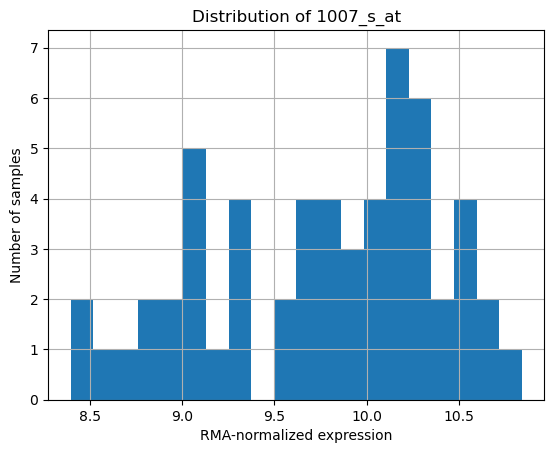

In [15]:
expression[gene_cols[0]].hist(bins=20)
plt.xlabel("RMA-normalized expression")
plt.ylabel("Number of samples")
plt.title(f"Distribution of {gene_cols[0]}")
plt.show()

## 2.3 Biological outcome structure

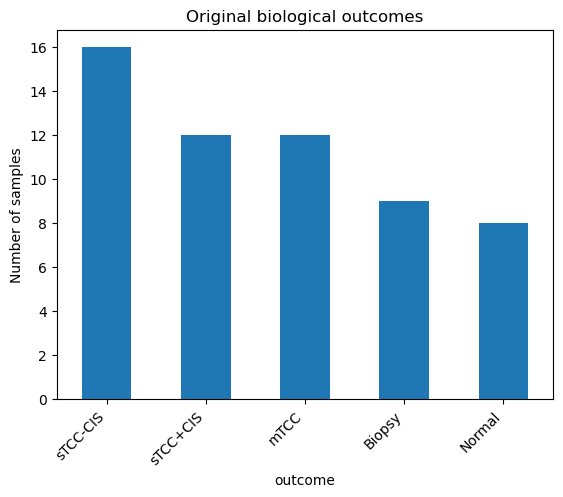

In [17]:
metadata["outcome"].value_counts().plot(kind="bar")
plt.ylabel("Number of samples")
plt.title("Original biological outcomes")
plt.xticks(rotation=45, ha="right")
plt.show()

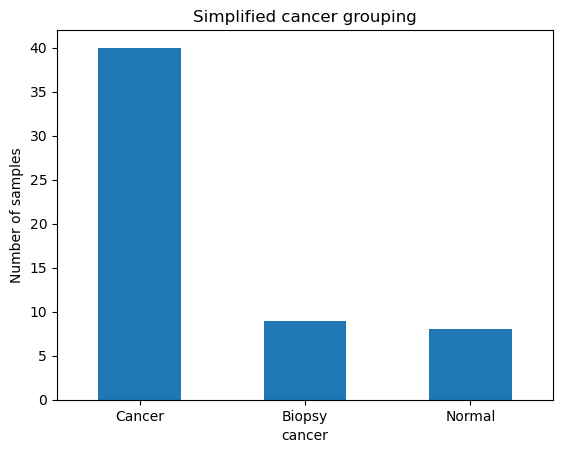

In [18]:
metadata["cancer"].value_counts().plot(kind="bar")
plt.ylabel("Number of samples")
plt.title("Simplified cancer grouping")
plt.xticks(rotation=0)
plt.show()

### Discussion

Why might the original `outcome` and simplified `cancer` variables be useful for different questions?

# 3. Data diagnostics

A diagnostic workflow does **not** mean that we must discover corrupted data.

Real datasets should be checked systematically even when they appear clean.

## 3.1 Are sample identifiers unique?

In [19]:
print("Expression IDs unique:", expression["sample_id"].is_unique)
print("Metadata IDs unique:", metadata["sample_id"].is_unique)

Expression IDs unique: True
Metadata IDs unique: True


## 3.2 Do both tables contain the same samples?

In [20]:
expr_ids = set(expression["sample_id"])
meta_ids = set(metadata["sample_id"])

print("Expression only:", expr_ids - meta_ids)
print("Metadata only:", meta_ids - expr_ids)

Expression only: set()
Metadata only: set()


## 3.4 Exact duplicate samples

In [22]:
print("Duplicate metadata rows:", metadata.duplicated().sum())
print("Duplicate expression rows:", expression.duplicated().sum())

Duplicate metadata rows: 0
Duplicate expression rows: 0


We can also ask whether any two expression rows are numerically identical.

In [23]:
expr_only = expression.set_index("sample_id")
print("Duplicated expression profiles:",
      expr_only.duplicated().sum())

Duplicated expression profiles: 0


## 3.5 Constant and low-variance features

In [24]:
variances = expression[gene_cols].var()

print("Constant features:", (variances == 0).sum())
print("Median feature variance:", variances.median())

Constant features: 0
Median feature variance: 0.1868963225451368


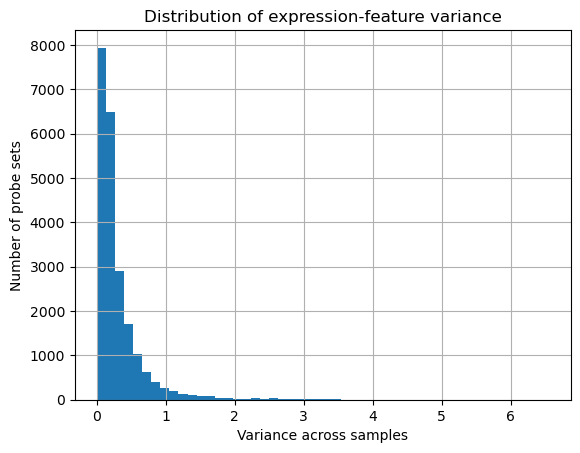

In [25]:
variances.hist(bins=50)
plt.xlabel("Variance across samples")
plt.ylabel("Number of probe sets")
plt.title("Distribution of expression-feature variance")
plt.show()


# 4. Data preparation

## 4.1 Merge measurements and metadata

Because both tables should have one row per sample, we can enforce a one-to-one relationship.

In [ ]:
df_real = metadata.merge(
    expression,
    on="sample_id",
    validate="one_to_one")

print(df_real.shape)
df_real.iloc[:5, :10]



(57, 22288)


,sample_id,sample,outcome,batch,cancer,1007_s_at,1053_at,117_at,121_at,1255_g_at
0,GSM71019.CEL,1,Normal,3,Normal,10.115170,5.345168,6.348024,8.901739,3.967672
1,GSM71020.CEL,2,Normal,2,Normal,8.628044,5.063598,6.663625,9.439977,4.466027
2,GSM71021.CEL,3,Normal,2,Normal,8.779235,5.113116,6.465892,9.540738,4.144885
3,GSM71022.CEL,4,Normal,3,Normal,9.248569,5.179410,6.116422,9.254368,4.189338
4,GSM71023.CEL,5,Normal,3,Normal,10.256841,5.181383,5.980457,8.798086,4.078509


## 4.2 Define a possible target

For demonstration, we will use the simplified `cancer` variable as the candidate target.

In [28]:
y_real = df_real["cancer"].copy()
y_real.value_counts()

cancer
Cancer    40
Biopsy     9
Normal     8
Name: count, dtype: int64

## 4.3 Define the real feature matrix

In [29]:
X_real = df_real[gene_cols].copy()

print("X:", X_real.shape)
print("y:", y_real.shape)

X: (57, 22283)
y: (57,)


Notice what is **not** in `X_real`:

- `sample_id`;
- `sample`;
- `outcome`;
- `batch`;
- `cancer`.

Some are identifiers, one is our target, and others are metadata whose inclusion would change the scientific question.




# 5. Artificial within-group similarity for the splitting exercise

The original bladderbatch samples are real biological samples, but the dataset does not provide the repeated-subject structure we want for this exercise. 

We will therefore construct **one pseudo-replicate per real sample** to intentioanlly spoil perfectly good dataset;)

For each real expression profile x_i, we create:

x_i_p = x_i + epsilon

epsilon - small noise

The pseudo-replicate is therefore **highly similar** to its source sample.

## 5.1 Generate pseudo-replicates

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

real = df_real.copy()
real["source_sample_id"] = real["sample_id"]
real["p_group"] = "TG_" + real["sample_id"].astype(str)


pseudo = df_real.copy()
pseudo["source_sample_id"] = pseudo["sample_id"]
pseudo["p_group"] = "TG_" + pseudo["sample_id"].astype(str)


# Give pseudo-replicates unique row/sample identifiers.
pseudo["sample_id"] = pseudo["sample_id"].astype(str) + "_pseudo"

# Small noise relative to the scale ofexpression.
noise_sigma = 0.25
noise = rng.normal(loc=0, scale=noise_sigma, size=(len(pseudo), len(gene_cols)))

pseudo.loc[:, gene_cols] = (pseudo[gene_cols].to_numpy() + noise)

df = pd.concat([real, pseudo], ignore_index=True)

print("Original samples:", len(real))
print("Pseudo-replicates:", len(pseudo))
print("pseudo rows:", len(df))
print("pseudo groups:", df["p_group"].nunique())

Original samples: 57
Pseudo-replicates: 57
pseudo rows: 114
pseudo groups: 57


### Important provenance rule

In [ ]:
df[["sample_id", "source_sample_id", "p_group",  "cancer", "batch"]].head(100)

,sample_id,source_sample_id,p_group,replicate_type,cancer,batch
0,GSM71019.CEL,GSM71019.CEL,TG_GSM71019.CEL,real,Normal,3
1,GSM71020.CEL,GSM71020.CEL,TG_GSM71020.CEL,real,Normal,2
2,GSM71021.CEL,GSM71021.CEL,TG_GSM71021.CEL,real,Normal,2
3,GSM71022.CEL,GSM71022.CEL,TG_GSM71022.CEL,real,Normal,3
4,GSM71023.CEL,GSM71023.CEL,TG_GSM71023.CEL,real,Normal,3
...,...,...,...,...,...,...
95,GSM71059.CEL_pseudo,GSM71059.CEL,TG_GSM71059.CEL,pseudo,Cancer,2
96,GSM71060.CEL_pseudo,GSM71060.CEL,TG_GSM71060.CEL,pseudo,Cancer,1
97,GSM71061.CEL_pseudo,GSM71061.CEL,TG_GSM71061.CEL,pseudo,Cancer,5
98,GSM71062.CEL_pseudo,GSM71062.CEL,TG_GSM71062.CEL,pseudo,Cancer,5


`source_sample_id`, and `p_group` are synthetic metadata.

The original `batch`, `outcome`, and `cancer` values remain those of the real sample.

## 5.2 Verify within-group similarity

Calculate the correlation between every real sample and its pseudo-replicate.

In [40]:
pair_correlations = []

for group, group_df in df.groupby("p_group"):
    if len(group_df) != 2:
        continue

    a = group_df.iloc[0][gene_cols].to_numpy(dtype=float)
    b = group_df.iloc[1][gene_cols].to_numpy(dtype=float)

    pair_correlations.append(np.corrcoef(a, b)[0, 1])

pair_correlations = pd.Series(pair_correlations)

pair_correlations

0     0.988667
1     0.985053
2     0.985383
3     0.986688
4     0.988498
5     0.990382
6     0.986295
7     0.985498
8     0.991439
9     0.987540
10    0.990484
11    0.990573
12    0.990550
13    0.988816
14    0.991196
15    0.990725
16    0.990049
17    0.990832
18    0.990575
19    0.989992
20    0.990883
21    0.990593
22    0.989993
23    0.991862
24    0.988173
25    0.990236
26    0.990778
27    0.988867
28    0.990580
29    0.988300
30    0.990677
31    0.988585
32    0.989745
33    0.990462
34    0.990887
35    0.989501
36    0.989639
37    0.989935
38    0.990465
39    0.991585
40    0.991002
41    0.991028
42    0.991675
43    0.990639
44    0.989077
45    0.991030
46    0.991051
47    0.990998
48    0.989341
49    0.988525
50    0.988374
51    0.988492
52    0.987395
53    0.985109
54    0.988932
55    0.987858
56    0.983029
dtype: float64

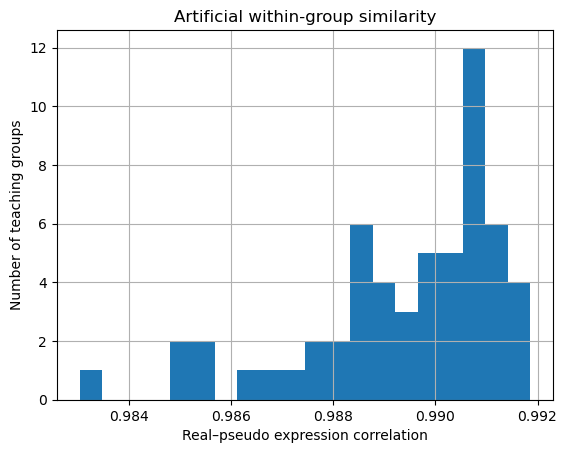

In [ ]:
pair_correlations.hist(bins=20)
plt.xlabel("Real–pseudo expression correlation")
plt.ylabel("Number of p groups")
plt.title("Artificial within-group similarity")
plt.show()

## 5.3 Introduce synthetic missing values (pseudoNA)
To spoil our good dataset even more we will intoduce some NA.
We alter expression measurements only; sample identifiers, metadata, targets, and grouping variables remain available for the exercise.

In [ ]:
pseudo_na_rng = np.random.default_rng(RANDOM_STATE + 1)

df_pseudona = df.copy()
expression_values = df_pseudona[gene_cols].to_numpy(dtype=float).copy()

# Remove 0.01% of expression cells

pseudo_na_fraction = 0.0001
n_expression_cells = expression_values.size
n_pseudona = max(1, int(round(n_expression_cells * pseudo_na_fraction)))
flat_indices = pseudo_na_rng.choice(
    n_expression_cells,
    size=n_pseudona,
    replace=False
)
rows, columns = np.unravel_index(
    flat_indices,
    expression_values.shape
)
expression_values[rows, columns] = np.nan
df_pseudona.loc[:, gene_cols] = expression_values

print("pseudo rows:", len(df_pseudona))
print("Synthetic missing expression cells:", df_pseudona[gene_cols].isna().sum().sum())

Teaching rows: 114
Synthetic missing expression cells: 254


## 5.4 Missing-value handling: detection, removal, and imputation

Missing values should be handled as part of the data-generating and modelling workflow. Start by detecting where they occur and how much information is affected.

There is no universally correct response:

- **Detection:** inspect missingness by table, row, column, and experimental group.
- **Removal:** remove rows or features only when the loss is acceptable and the rule is scientifically justified. In high-dimensional data, dropping every row with any missing feature can discard most observations.
- **Imputation:** replace missing values using a rule such as a median, mean, K-nearest neighbours, or a model-based method. The imputation rule must be fitted on the training data only, then applied to the test data, so that test-set information does not leak into training.

The following cells are a demonstration using the synthetic pseudoNA copy.

In [45]:
missing_by_column = df_pseudona[gene_cols].isna().sum()
missing_by_row = df_pseudona[gene_cols].isna().sum(axis=1)

print("Total missing expression cells:", int(missing_by_column.sum()))
print("Features with at least one missing value:", int((missing_by_column > 0).sum()))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))

display(missing_by_column[missing_by_column > 0].head())
missing_by_row.describe()

Total missing expression cells: 254
Features with at least one missing value: 253
Rows with at least one missing value: 99


200769_s_at    1
200775_s_at    1
200819_s_at    1
200835_s_at    1
200981_x_at    1
dtype: int64

count    114.000000
mean       2.228070
std        1.545963
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        7.000000
dtype: float64

### Removal as a possible strategy

Complete-row removal is easy to write, but it can be very costly. Feature removal is another option, although removing a feature because of one missing value may also discard useful measurements. Compare both consequences before choosing a rule.

In [46]:
df_rows_removed = df_pseudona.dropna(subset=gene_cols)
features_without_missing = [
    column for column in gene_cols
    if df_pseudona[column].notna().all()
]
X_features_removed = df_pseudona[features_without_missing].copy()

print("Rows before removal:", len(df_pseudona))
print("Rows after complete-row removal:", len(df_rows_removed))
print("Features before removal:", len(gene_cols))
print("Features after removal of any incomplete feature:", X_features_removed.shape[1])

Rows before removal: 114
Rows after complete-row removal: 15
Features before removal: 22283
Features after removal of any incomplete feature: 22030


### Imputation as a possible strategy

Here we use median imputation as a simple baseline. In a real analysis, the choice should reflect the measurement process and the scientific question. 

In [54]:

X_pseudona = df_pseudona[gene_cols].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_pseudona), columns=gene_cols)


X_imputed.isna().sum().sum()

np.int64(0)

# 6. Splits

## 6.1 Naive random row-wise split

In [55]:
row_indices = np.arange(len(df))

train_idx_random, test_idx_random = train_test_split(
    row_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["cancer"])

random_train = df.iloc[train_idx_random]
random_test = df.iloc[test_idx_random]

Lets check if some pseudo groups is present in both sets

In [58]:
random_train_groups = set(random_train["p_group"])
random_test_groups = set(random_test["p_group"])

leaked_groups = random_train_groups & random_test_groups

print("Groups appearing in both train and test", len(leaked_groups))

list(sorted(leaked_groups))

Groups appearing in both train and test 25


['TG_GSM71020.CEL',
 'TG_GSM71021.CEL',
 'TG_GSM71023.CEL',
 'TG_GSM71025.CEL',
 'TG_GSM71029.CEL',
 'TG_GSM71039.CEL',
 'TG_GSM71041.CEL',
 'TG_GSM71042.CEL',
 'TG_GSM71043.CEL',
 'TG_GSM71049.CEL',
 'TG_GSM71050.CEL',
 'TG_GSM71051.CEL',
 'TG_GSM71053.CEL',
 'TG_GSM71056.CEL',
 'TG_GSM71058.CEL',
 'TG_GSM71059.CEL',
 'TG_GSM71060.CEL',
 'TG_GSM71062.CEL',
 'TG_GSM71064.CEL',
 'TG_GSM71066.CEL',
 'TG_GSM71067.CEL',
 'TG_GSM71068.CEL',
 'TG_GSM71071.CEL',
 'TG_GSM71074.CEL',
 'TG_GSM71075.CEL']

These rows are not independent. A pseudo-replicate in the test set may be almost identical to its source sample in training.


## 6.2 Group-aware split

In [59]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE)

train_idx, test_idx = next(
    splitter.split(
        df[gene_cols],
        df["cancer"],
        groups=df["p_group"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

In [60]:
train_groups = set(train_df["p_group"])
test_groups = set(test_df["p_group"])

print("Group overlap", train_groups & test_groups)

Group overlap set()


Expected:

```text
set()
```

## 6.3 Verify that each original/pseudo pair stays together

In [61]:
split_membership = pd.Series("test", index=df.index)
split_membership.iloc[train_idx] = "train"

check = (
    df.assign(split=split_membership)
      .groupby("p_group")["split"]
      .nunique())

print("Groups split across partitions",(check > 1).sum())

Groups split across partitions 0


### Discussion

For the artificial pseud data, `p_group` plays the role that variables such as these often play in real studies:

- patient ID;
- donor ID;
- animal ID;
- family;
- experimental unit;
- repeated-measure subject;
- original image before augmentation;
- original molecule before generating conformers.

# 7. Real batch effects and confounding

Now we return to a property that is **not synthetic**.

`batch` is real metadata from the bladderbatch experiment and reflects the dates on which microarrays were processed.

## 7.1 Examine the experimental design

Use **only the real samples** here so that our pseudo-replicates do not alter counts.

In [ ]:
pd.crosstab(real["batch"], real["cancer"],margins=True)

cancer,Biopsy,Cancer,Normal,All
batch,,,,
1,0,11,0,11
2,0,14,4,18
3,0,0,4,4
4,5,0,0,5
5,4,15,0,19
All,9,40,8,57


In [ ]:
pd.crosstab(real["batch"], real["cancer"], normalize="index").round(2)

cancer,Biopsy,Cancer,Normal
batch,,,
1,0.00,1.00,0.00
2,0.00,0.78,0.22
3,0.00,0.00,1.00
4,1.00,0.00,0.00
5,0.21,0.79,0.00


### Question

Is biological class independent of processing batch?

## 7.2 Original outcomes by batch

In [65]:
outcome_batch = pd.crosstab(real["batch"], real["outcome"])

outcome_batch

outcome,Biopsy,Normal,mTCC,sTCC+CIS,sTCC-CIS
batch,,,,,
1,0,0,11,0,0
2,0,4,1,0,13
3,0,4,0,0,0
4,5,0,0,0,0
5,4,0,0,12,3


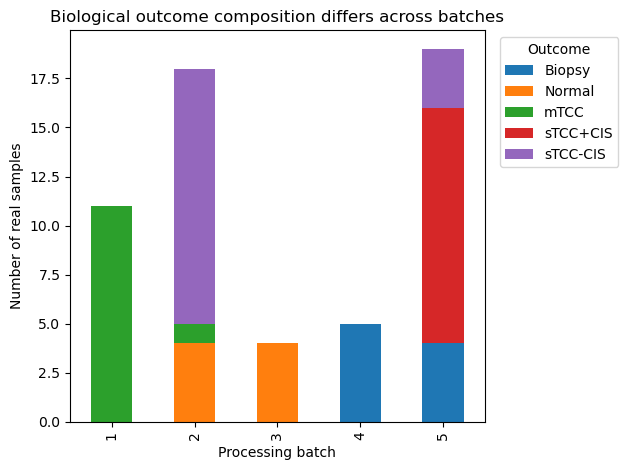

In [66]:
outcome_batch.plot(kind="bar", stacked=True)

plt.xlabel("Processing batch")
plt.ylabel("Number of real samples")
plt.title("Biological outcome composition differs across batches")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 8. Visualizing batch structure

We will use PCA only as a **diagnostic visualization** here.

The mathematical details of PCA will be covered in a later practical.

## 8.1 Select highly variable features for visualization

Using all 22,283 features is unnecessary for a quick exploratory plot. So we will keep only top 1000 by variation

In [68]:
real_X = real[gene_cols]

feature_variance = real_X.var().sort_values(ascending=False)
top_genes = feature_variance.head(1000).index

X_vis = real_X[top_genes]

## 8.2 Standardize and project to two dimensions

In [69]:
X_scaled = StandardScaler().fit_transform(X_vis)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "batch": real["batch"].astype(str).values,
    "cancer": real["cancer"].astype(str).values,
    "outcome": real["outcome"].astype(str).values
})

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)

Explained variance: [0.279 0.166]


## 8.3 Color by batch

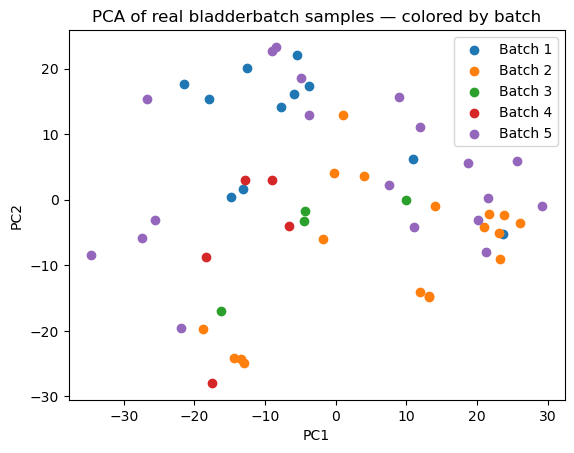

In [70]:
for batch, group in pca_df.groupby("batch"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=f"Batch {batch}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of real bladderbatch samples — colored by batch")
plt.legend()
plt.show()

## 8.4 Color by cancer class

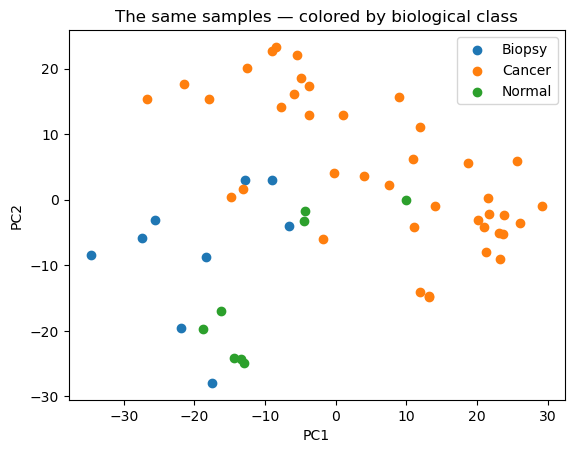

In [71]:
for label, group in pca_df.groupby("cancer"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("The same samples — colored by biological class")
plt.legend()
plt.show()

### Discussion

Look at the **same geometric arrangement** twice:

1. colored by processing batch;
2. colored by biological target.

If batch and target are associated, how confidently can we interpret a predictive signal as biology?

# 9. Prepare ML-ready train and test sets

Return to the group-aware split.

In [72]:
X_train = train_df[gene_cols].copy()
X_test = test_df[gene_cols].copy()

y_train = train_df["cancer"].copy()
y_test = test_df["cancer"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (84, 22283)
X_test: (30, 22283)
y_train: (84,)
y_test: (30,)


Check missingness before proceeding.

In [73]:
print("Missing train values:",
      X_train.isna().sum().sum())

print("Missing test values:",
      X_test.isna().sum().sum())

Missing train values: 0
Missing test values: 0



# 11. Independent task - UCI Mice Protein Expression

Now apply the same general workflow to the UCI Mice Protein Expression dataset.

    Data_Cortex_Nuclear.xls

The dataset is available from the UCI Machine Learning Repository at:
https://archive.ics.uci.edu/dataset/342/mice%2Bprotein%2Bexpression

The dataset contains 1,080 rows, expression levels for 77 proteins or protein modifications, measurements from 72 mice, and 15 measurements per mouse. It also includes MouseID, Genotype, Treatment, Behavior, and an eight-level composite class.

### What are the 15 measurements?

For each mouse sample, the original reverse-phase protein array (RPPA) experiment used three technical replicate spots at each point of a five-point dilution series:

    1 mouse × 5 dilution points × 3 technical replicates = 15 rows

The dilution points are different concentrations of the same sample, and the replicate spots are repeated technical measurements. They are not 15 independent mice or 15 biological replicates. The public UCI spreadsheet does not contain separate dilution-level or replicate-number columns, so the exact dilution curve cannot be reconstructed  alone, meaning you need to select one dilution level. In the distributed file, labels such as `309_1` through `309_15` are row-level measurement identifiers: the part before the final underscore identifies the biological mouse, while the suffix identifies the measurement record.

Create a derived grouping variable before splitting:

    mice["mouse_id"] = mice["MouseID"].astype(str).str.rsplit("_", n=1).str[0]

Your goal is to turn the data into a defensible ML-ready dataset while keeping measurement, mouse, experimental-condition, and target roles separate.

## Required tasks

### A. Data presentation

Identify:

- what one row represents and what one biological mouse represents;
- the 77 numerical protein-expression measurements;
- MouseID, derived mouse_id, and the experimental metadata;
- one possible prediction target.

Consider Genotype as a primary target: control versus trisomy. You may choose the eight-level class target instead, but explain why. Remember that class is constructed from genotype, behavior, and treatment.

### B. EDA and tidy-data assessment

- load the Excel file and inspect dimensions, column names, and data types;
- inspect the distributions of Genotype, Treatment, Behavior, and class;
- check how many rows and how many unique mice belong to each group;
- visualize at least three biologically meaningful relationships.

Possible plots include:

- distributions of selected protein measurements by genotype;
- a PCA or two-dimensional projection colored by genotype, treatment, or behavior;
- protein-expression relationships or a correlation heatmap;
- the number of measurements per derived mouse_id.

For every plot, state the biological question it addresses.

### C. Diagnostics

Check:

- missingness in the protein measurements and metadata;
- duplicate rows and duplicate MouseID measurement records;
- whether every mouse has the expected number of repeated measurements;
- unusual categories or inconsistent labels;
- non-finite, negative, or otherwise implausible expression values;
- highly correlated or redundant protein variables;
- whether any candidate predictor is a deterministic part of the target.

### D. Preparation

Choose one supervised-learning problem and create:

    X
    y

Explain every variable that you exclude.

For a genotype-prediction question, start with the 77 protein measurements as candidate features. Exclude:

- MouseID and derived mouse_id, because the raw identifier identifies a measurement record and the derived identifier identifies the biological unit;
- the target column;
- class when Genotype is the target, because it contains genotype information;
- Treatment and Behavior unless you explicitly want a conditional prediction question and can justify their use.

Use the real missing values in the dataset to compare a defensible removal rule with an imputation rule. If you impute, fit the imputer on the training data only and apply it to the test data.

### E. Split

Create an appropriate training/test split.

For generalization to unseen mice:

- derive and group by mouse_id;
- keep all 15 measurements from a mouse in the same partition;
- use a group-aware split such as GroupShuffleSplit or StratifiedGroupKFold when appropriate.

Explain:

- what population you want the model to generalize to;
- why a row-wise random split would give an over-optimistic estimate;
- what the independent biological unit is;
- whether stratification is needed and whether it is compatible with your grouping strategy.

### F. Confounding and distribution structure

Investigate associations between the target and:

- treatment;
- behavior;
- genotype;
- the composite class;
- the number of measurements per mouse.

Use cross-tabulations and plots to ask:

- are treatment and behavior balanced across genotype?
- does the composite class encode the target directly?
- do some mice or experimental groups contribute different numbers of rows?
- could a model exploit experimental design structure instead of protein biology?

Identify at least one plausible source of confounding, target leakage, or distribution shift.

### G. Deliverable

Provide:

- X_train, X_test, y_train, y_test;
- a table documenting the role of each column;
- a missingness report and a justified removal or imputation decision;
- plots if you want;
- a short Markdown interpretation describing:
  - the ML question;
  - the biological unit;
  - the split strategy;
  - one potential source of bias, confounding, or leakage.

## Optional advanced task

Compare two evaluation questions:

1. a random row-wise train/test split;
2. a mouse-grouped train/test split.

Are these evaluating the same kind of generalization?

As a second extension, compare predicting Genotype with predicting the composite class. Which question is biologically clearer, and which variables must be excluded to avoid target leakage?


# 12. Take-home messages

- Biological data should be understood before they are modelled.
- High-dimensional omics commonly have \(p \gg n\).
- Metadata are part of the scientific problem, not administrative decoration.
- Data diagnostics include checking experimental structure, not only detecting `NaN`.
- Similar or repeated observations must remain in the same split.
- Data augmentation and pseudo-replication can produce leakage if derivatives cross the split boundary.
- Batch effects are technical signals that a model can exploit.
- Batch–target confounding makes biological interpretation especially difficult.
- Train/test splitting is part of experimental design.
- A valid ML pipeline begins with a valid scientific question.

In [4]:
mice = pd.read_excel(DATA / "Data_Cortex_Nuclear.xls")

mice["mouse_id"] = mice["MouseID"].astype(str).str.rsplit("_", n=1).str[0]

meta_cols = ["MouseID", "mouse_id", "Genotype", "Treatment", "Behavior", "class"]
protein_cols = [c for c in mice.columns if c not in meta_cols]

print("Shape:", mice.shape)
print("Proteins:", len(protein_cols))
print("Unique mice:", mice["mouse_id"].nunique())
mice.head()

Shape: (1080, 83)
Proteins: 77
Unique mice: 72


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,mouse_id
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m,309
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m,309
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m,309
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m,309
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m,309


In [5]:
mice[meta_cols].info()
print(mice[protein_cols].dtypes.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MouseID    1080 non-null   str   
 1   mouse_id   1080 non-null   object
 2   Genotype   1080 non-null   str   
 3   Treatment  1080 non-null   str   
 4   Behavior   1080 non-null   str   
 5   class      1080 non-null   str   
dtypes: object(1), str(5)
memory usage: 50.8+ KB
float64    77
Name: count, dtype: int64


In [8]:
for col in ["Genotype", "Treatment", "Behavior", "class"]:
    print(pd.DataFrame({"rows": mice[col].value_counts(),"mice": mice.groupby(col)["mouse_id"].nunique()}))

          rows  mice
Genotype            
Control    570    38
Ts65Dn     510    34
           rows  mice
Treatment            
Memantine   570    38
Saline      510    34
          rows  mice
Behavior            
C/S        525    35
S/C        555    37
        rows  mice
class             
c-CS-m   150    10
c-CS-s   135     9
c-SC-m   150    10
c-SC-s   135     9
t-CS-m   135     9
t-CS-s   105     7
t-SC-m   135     9
t-SC-s   135     9


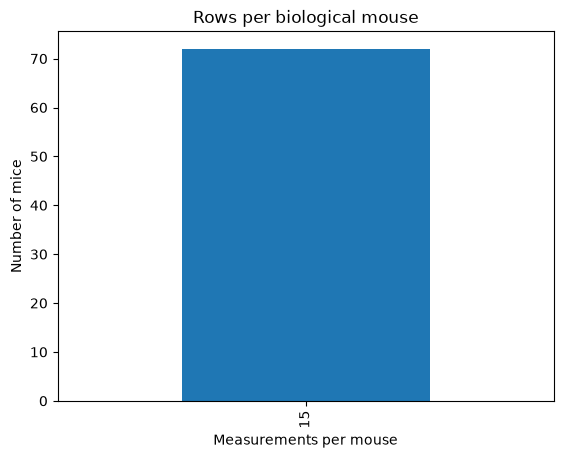

In [9]:
mice.groupby("mouse_id").size().value_counts().plot(kind="bar")
plt.xlabel("Measurements per mouse")
plt.ylabel("Number of mice")
plt.title("Rows per biological mouse")
plt.show()

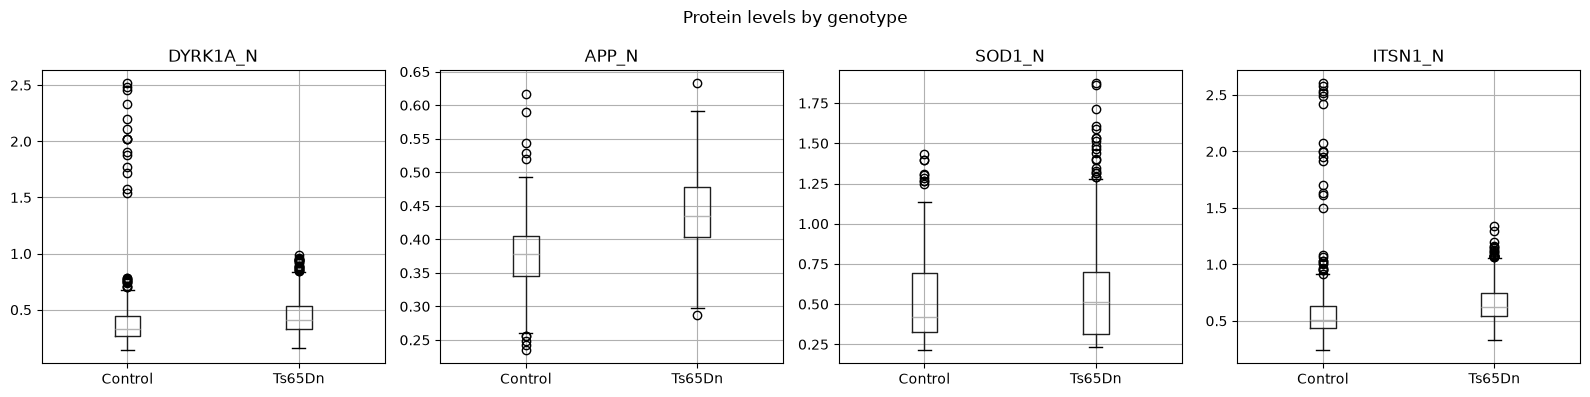

In [10]:
selected = ["DYRK1A_N", "APP_N", "SOD1_N", "ITSN1_N"]

fig, axes = plt.subplots(1, len(selected), figsize=(16, 4))
for ax, protein in zip(axes, selected):
    mice.boxplot(column=protein, by="Genotype", ax=ax)
    ax.set_title(protein)
    ax.set_xlabel("")
plt.suptitle("Protein levels by genotype")
plt.tight_layout()
plt.show()

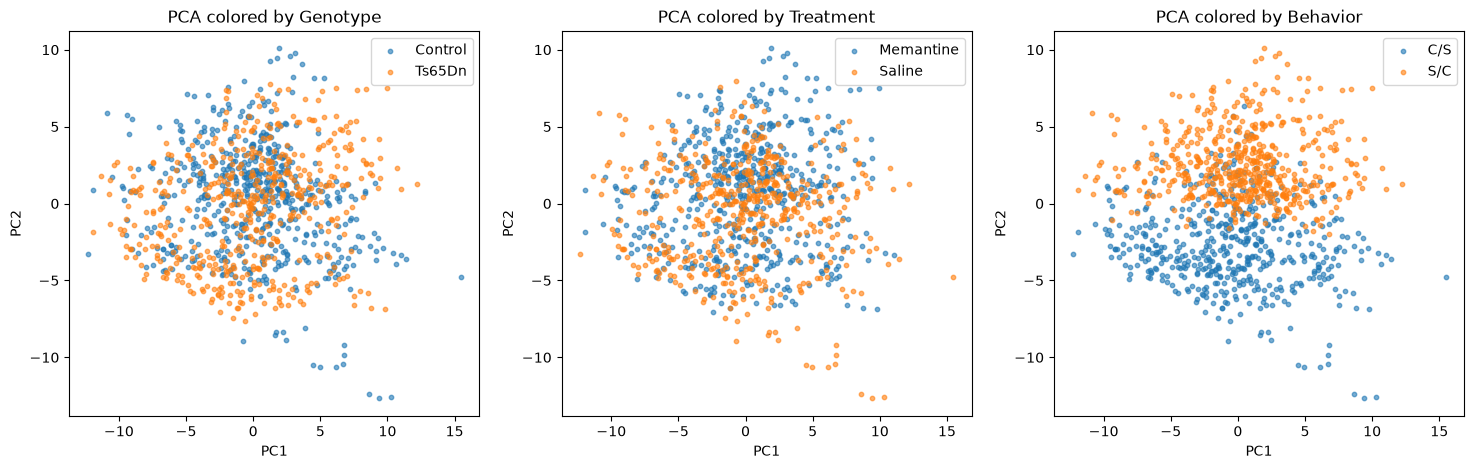

In [11]:
X_eda = mice[protein_cols].fillna(mice[protein_cols].median())
coords_m = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X_eda))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Genotype", "Treatment", "Behavior"]):
    for label, idx in mice.groupby(col).groups.items():
        ax.scatter(coords_m[idx, 0], coords_m[idx, 1], label=label, s=10, alpha=0.6)
    ax.set_title(f"PCA colored by {col}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend()
plt.show()

Графік 1: дизайн збалансований, 72 миші * 15 вимірювань; біологічна одиниця — миша.
Графік 2: APP_N вищий у Ts65Dn, це відповідає трисомії; в інших білках різниця слабка, а викиди може належать окремим мишам.
Графік 3: головна вісь варіації пов'язана з Behavior, а не з Genotype

In [12]:
missing_by_col = mice[protein_cols].isna().sum().sort_values(ascending=False)

print("Missing in metadata:", mice[meta_cols].isna().sum().sum())
print("Missing protein cells:", missing_by_col.sum())
print("Proteins with any missing:", (missing_by_col > 0).sum(), "/", len(protein_cols))
missing_by_col[missing_by_col > 0].head(15)

Missing in metadata: 0
Missing protein cells: 1396
Proteins with any missing: 49 / 77


BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
ELK_N          18
Bcatenin_N     18
MEK_N           7
P38_N           3
TRKA_N          3
RSK_N           3
APP_N           3
SOD1_N          3
MTOR_N          3
dtype: int64

In [13]:
missing_by_row = mice[protein_cols].isna().sum(axis=1)
print(missing_by_row.value_counts().sort_index())
missing_by_mouse = (mice[protein_cols].isna().groupby(mice["mouse_id"]).sum().sum(axis=1))
missing_by_mouse[missing_by_mouse > 0].sort_values(ascending=False).head(15)

0     552
1     165
2     120
3     117
4     104
5      19
43      3
Name: count, dtype: int64


mouse_id
3426      129
50810F     75
3479       64
3417       60
322        60
3605       60
3424       60
3420       60
3418       60
365        48
3419       45
294        45
3507       45
3416       45
364        45
dtype: int64

In [14]:
mice[protein_cols].isna().sum(axis=1).groupby(mice["Genotype"]).sum()

Genotype
Control    787
Ts65Dn     609
dtype: int64

In [15]:
print("Duplicate rows:", mice.duplicated().sum())
print("Duplicate MouseID:", mice["MouseID"].duplicated().sum())
print("Duplicate protein profiles:", mice[protein_cols].duplicated().sum())

Duplicate rows: 0
Duplicate MouseID: 0
Duplicate protein profiles: 0


In [16]:
for col in ["Genotype", "Treatment", "Behavior", "class"]:
    print(col, sorted(mice[col].unique()))

Genotype ['Control', 'Ts65Dn']
Treatment ['Memantine', 'Saline']
Behavior ['C/S', 'S/C']
class ['c-CS-m', 'c-CS-s', 'c-SC-m', 'c-SC-s', 't-CS-m', 't-CS-s', 't-SC-m', 't-SC-s']


In [17]:
vals = mice[protein_cols]
print("Non-finite:", (~np.isfinite(vals.fillna(0))).sum().sum())
print("Negative:", (vals < 0).sum().sum())
print("Zero:", (vals == 0).sum().sum())
vals[vals < 0].stack()

Non-finite: 0
Negative: 1
Zero: 0


0     DYRK1A_N    NaN
      ITSN1_N     NaN
      BDNF_N      NaN
      NR1_N       NaN
      NR2A_N      NaN
                   ..
1079  SYP_N       NaN
      H3AcK18_N   NaN
      EGR1_N      NaN
      H3MeK4_N    NaN
      CaNA_N      NaN
Length: 83160, dtype: float64

In [19]:
corr = mice[protein_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False)
print("Pairs with corr > 0.9:", (high_pairs > 0.9).sum())
high_pairs.head(10)

Pairs with corr > 0.9: 10


ARC_N     pS6_N         1.000000
DYRK1A_N  BRAF_N        0.959578
          ITSN1_N       0.959512
NR1_N     pNR1_N        0.947872
DYRK1A_N  pERK_N        0.945719
pERK_N    BRAF_N        0.926984
ITSN1_N   BRAF_N        0.917608
NR1_N     Bcatenin_N    0.914610
pNR1_N    pNR2B_N       0.906504
ITSN1_N   pERK_N        0.906289
dtype: float64

In [20]:
pd.crosstab(mice["class"], mice["Genotype"])

Genotype,Control,Ts65Dn
class,,
c-CS-m,150,0
c-CS-s,135,0
c-SC-m,150,0
c-SC-s,135,0
t-CS-m,0,135
t-CS-s,0,105
t-SC-m,0,135
t-SC-s,0,135


In [21]:
mice_clean = mice.copy()

mice_clean.loc[mice_clean["RRP1_N"] < 0, "RRP1_N"] = np.nan

mice_clean = mice_clean.drop(columns=["pS6_N"])

row_missing_frac = mice_clean[[c for c in protein_cols if c != "pS6_N"]].isna().mean(axis=1)
print("Rows removed:", mice_clean.loc[row_missing_frac > 0.5, "MouseID"].tolist())
mice_clean = mice_clean[row_missing_frac <= 0.5].reset_index(drop=True)

col_missing_frac = mice_clean.isna().mean()
drop_proteins = col_missing_frac[col_missing_frac > 0.10].index.tolist()
print("Proteins removed:", drop_proteins)
mice_clean = mice_clean.drop(columns=drop_proteins)

protein_cols_clean = [c for c in mice_clean.columns if c not in meta_cols]
print("Shape before:", mice.shape, "after:", mice_clean.shape)
print("Proteins left:", len(protein_cols_clean))
print("Remaining NaN:", mice_clean[protein_cols_clean].isna().sum().sum())

Rows removed: ['3426_13', '3426_14', '3426_15']
Proteins removed: ['BAD_N', 'BCL2_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N']
Shape before: (1080, 83) after: (1077, 77)
Proteins left: 71
Remaining NaN: 110


Почистили датасет від неможливих від'ємних значень, від сильно (100%) корельованого гену pS6_N, рядків, де пропущено більше половини білків. Теж прибрали там де білки з часткою пропусків більше 10%. 

In [22]:
X_all = mice_clean[protein_cols_clean]
y_all = mice_clean["Genotype"]
groups = mice_clean["mouse_id"]

print("X:", X_all.shape, "y:", y_all.shape, "mice:", groups.nunique())

X: (1077, 71) y: (1077,) mice: 72


In [25]:
roles = pd.DataFrame({
    "column": ["MouseID", "mouse_id", "Genotype", "Treatment", "Behavior", "class",
               "71 proteins", "pS6_N", "BCL2_N, H3MeK4_N, BAD_N, EGR1_N, H3AcK18_N"],
    "role": ["measurement ID", "grouping variable", "target", "experimental condition",
             "experimental condition", "composite label", "features", "removed", "removed"],
    "in X": ["no", "no", "no (y)", "no", "no", "no", "yes", "no", "no"],
    "reason": [
        "identifies a row/record, not biology",
        "biological unit; used only for group split",
        "prediction target",
        "different scientific question i decided not to discover and possible leakage",
        "different scientific question",
        "contains Genotype -> target leakage",
        "protein expression levels",
        "identical to ARC_N (r = 1.0)",
        ">10% missing values",
    ],
})
roles

,column,role,in X,reason
0,MouseID,measurement ID,no,"identifies a row/record, not biology"
1,mouse_id,grouping variable,no,biological unit; used only for group split
2,Genotype,target,no (y),prediction target
3,Treatment,experimental condition,no,different scientific question i decided not to...
4,Behavior,experimental condition,no,different scientific question
5,class,composite label,no,contains Genotype -> target leakage
6,71 proteins,features,yes,protein expression levels
7,pS6_N,removed,no,identical to ARC_N (r = 1.0)
8,"BCL2_N, H3MeK4_N, BAD_N, EGR1_N, H3AcK18_N",removed,no,>10% missing values


In [27]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
train_idx_m, test_idx_m = next(sgkf.split(X_all, y_all, groups=groups))

X_train = X_all.iloc[train_idx_m].copy()
X_test  = X_all.iloc[test_idx_m].copy()
y_train = y_all.iloc[train_idx_m].copy()
y_test  = y_all.iloc[test_idx_m].copy()

print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print("Mouse overlap:", set(groups.iloc[train_idx_m]) & set(groups.iloc[test_idx_m]))
print("Mice per genotype, train:",mice_clean.iloc[train_idx_m].groupby("Genotype")["mouse_id"].nunique().to_dict())
print("Mice per genotype, test:",mice_clean.iloc[test_idx_m].groupby("Genotype")["mouse_id"].nunique().to_dict())

Train rows: 807 | Test rows: 270
Mouse overlap: set()
Mice per genotype, train: {'Control': 29, 'Ts65Dn': 25}
Mice per genotype, test: {'Control': 9, 'Ts65Dn': 9}


In [28]:
split_label = pd.Series("test", index=mice_clean.index)
split_label.iloc[train_idx_m] = "train"
print("Mice split across partitions:",(split_label.groupby(mice_clean["mouse_id"]).nunique() > 1).sum())

Mice split across partitions: 0


In [34]:
imputer_m = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer_m.fit_transform(X_train), columns=protein_cols_clean, index=X_train.index)
X_test  = pd.DataFrame(imputer_m.transform(X_test),columns=protein_cols_clean, index=X_test.index)

In [38]:
print("X_train:", X_train.shape,", X_test:", X_test.shape)
print("y_train:", y_train.value_counts().to_dict())
print("y_test:", y_test.value_counts().to_dict())

X_train: (807, 71) , X_test: (270, 71)
y_train: {'Control': 435, 'Ts65Dn': 372}
y_test: {'Control': 135, 'Ts65Dn': 135}


In [39]:
mice_level = mice_clean.drop_duplicates("mouse_id")[["mouse_id", "Genotype", "Treatment", "Behavior", "class"]]
print("Mice:", len(mice_level))

Mice: 72


In [41]:
display(pd.crosstab(mice_level["Genotype"], mice_level["Treatment"], margins=True))
display(pd.crosstab(mice_level["Genotype"], mice_level["Behavior"], margins=True))

Treatment,Memantine,Saline,All
Genotype,,,
Control,20,18,38
Ts65Dn,18,16,34
All,38,34,72


Behavior,C/S,S/C,All
Genotype,,,
Control,19,19,38
Ts65Dn,16,18,34
All,35,37,72


In [42]:
pd.crosstab([mice_level["Genotype"], mice_level["Behavior"]], mice_level["Treatment"])

Treatment          Memantine  Saline
Genotype Behavior                   
Control  C/S              10       9
         S/C              10       9
Ts65Dn   C/S               9       7
         S/C               9       9

In [43]:
rows_per_mouse = mice_clean.groupby("mouse_id").size().rename("n_rows")
mice_level = mice_level.merge(rows_per_mouse, on="mouse_id")
print(mice_level.groupby("Genotype")["n_rows"].describe())
print(mice_level.groupby("class")["mouse_id"].count())

          count       mean       std   min   25%   50%   75%   max
Genotype                                                          
Control    38.0  15.000000  0.000000  15.0  15.0  15.0  15.0  15.0
Ts65Dn     34.0  14.911765  0.514496  12.0  15.0  15.0  15.0  15.0
class
c-CS-m    10
c-CS-s     9
c-SC-m    10
c-SC-s     9
t-CS-m     9
t-CS-s     7
t-SC-m     9
t-SC-s     9
Name: mouse_id, dtype: int64


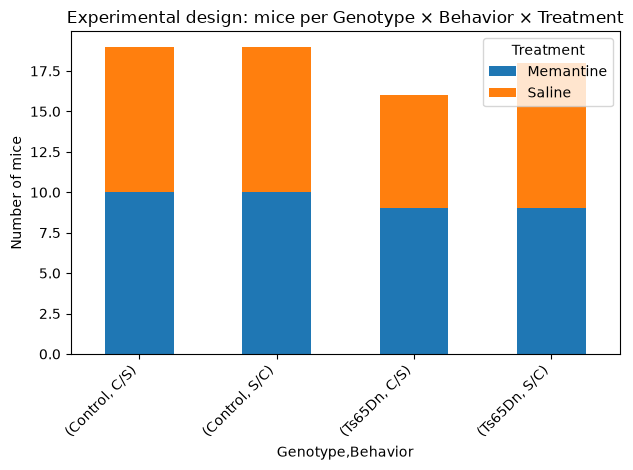

In [45]:
pd.crosstab([mice_level["Genotype"], mice_level["Behavior"]],mice_level["Treatment"]).plot(kind="bar", stacked=True)
plt.ylabel("Number of mice")
plt.title("Experimental design: mice per Genotype × Behavior × Treatment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

F. Confounding and distribution structure

- Чи збалансовані Treatment і Behavior між генотипами? Приблизно так (Treatment: 20/18 vs 18/16; Behavior: 19/19 vs 16/18 мишей).
- Чи кодує class таргет? Так, повністю: перша літера (c/t) — це генотип. class виключено з X як пряме джерело leakagа.
- Чи дають групи різну кількість рядків? Так: у класах від 7 до 10 мишей (105–150 рядків); одна миша (3426) має 12 рядків після видалення неповних вимірювань.
- Чи може модель використати структуру дизайну замість біології?
  - На PCA найсильніше розділення — за Behavior, а не за Genotype. Behavior збалансований, тому напряму генотип не підміняє, але це найбільше джерело варіації, яке модель мусить «обійти».
  - Вимірювання однієї миші дуже схожі — без групового спліту модель вчила б ідентичність миші.

# 13. Data-preparation readiness checklist

Use this checklist before starting any biological machine-learning analysis. Tick an item only after inspecting the data or documenting a justified decision. It is dataset-independent and can be reused in later practicals.

## Scientific purpose and provenance

- [-] Is the biological question and prediction task stated clearly?
- [ ] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)?
- [ ] Do I know where the data came from, how they were generated, and under which license or access conditions they may be used?
- [ ] Have I recorded the data version, processing history, and transformations already applied?

## Table shape and identifiers

- [ ] Is the table tidy: one observation per row, one variable per column, and one value per cell?
- [ ] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool?
- [ ] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns?
- [ ] Can every feature and observation be traced back to its source?
- [ ] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order?

## Types, values, and measurement meaning

- [ ] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
- [ ] Are units, scales, encodings, reference categories, and detection limits understood?
- [ ] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?
- [ ] Are normalization, scaling, log transformation, and batch-correction steps documented?

## Missing values

- [ ] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
- [ ] Have I measured missingness by row, column, group, and relevant batch or time variable?
- [ ] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
- [ ] Have I justified whether to retain, remove, or impute missing values?
- [ ] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?

## Replicates, dependence, and grouping

- [ ] Have I checked for exact duplicates and near-duplicate observations?
- [ ] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [ ] Is the independent biological unit identified by a grouping variable?
- [ ] Will all related observations and their derivatives remain in the same train/validation/test split?
- [ ] If I created augmented or synthetic observations, is their provenance recorded and reproducible?

## Target, leakage, and study design

- [ ] Is the target defined before modelling, with its classes or values checked for balance and validity?
- [ ] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
- [ ] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
- [ ] Have I checked whether the target is associated with a technical or grouping variable?
- [ ] Does the planned split represent the biological generalization question?

## Reproducibility and decision record

- [ ] Are random seeds, software versions, file names, and input/output shapes recorded?
- [ ] Are all preprocessing steps placed in a reproducible pipeline?
- [ ] Have I recorded unresolved data-quality concerns and the decisions made about them?
- [ ] Can another person explain what each row, column, feature, target, and grouping variable means?

## Short preparation summary

Before modelling, write down:

- biological unit: ...
- number of observations and features: ...
- target and feature definition: ...
- missing-value decision: ...
- replicate/grouping decision: ...
- main confounder or possible leakage source: ...
- train/test split and why it is appropriate: ...
- remaining concerns: ...